In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yaml
import re
import networkx as nx
from itertools import combinations
import json
import os

### conversion to pd df

In [3]:
df_users = pd.read_csv('DATA1/users.csv')
print(df_users.shape)
df_users.head(2)

(3293, 5)


,id,name,address,phone,email
0,44533,Hoyt Carter,"Apt. 300 8604 Ashlyn Wells, Effertzstad, ID 02997",(462) 385-4294,mckinley.rowe@harber.example
1,46128,Marco Kulas,"Apt. 538 816 Bechtelar Ferry, Lincolnhaven, KS...",913.466.4487,francisco@murray-cronin.test


In [4]:
df_orders = pd.read_parquet('DATA1/orders.parquet', engine='pyarrow')
print(df_orders.shape)
df_orders.head(2)

(11237, 7)


,id,user_id,book_id,quantity,unit_price,timestamp,shipping
0,71389,47288,18976,2,27.00$,10/01/24 10:38:08 A.M.,NaN
1,66343,47049,19403,1,€50¢50,10:14;19-Oct-2024,"4940 Arnoldo Keys, West Arnette, KS 77599"


In [5]:
with open('DATA1/books.yaml', 'r') as f:
    books_data = yaml.safe_load(f)

df_books = pd.DataFrame(books_data)
print(df_books.shape)
df_books.columns = df_books.columns.str.lstrip(':')

(753, 6)


In [6]:
df_books.head(2)

,id,title,author,genre,publisher,year
0,19199,The Yellow Meads of Asphodel,Carolyne West,Classic,Mainstream Publishing,2009
1,19398,From Here to Eternity,"Rep. Heath Stiedemann, Gino Welch, Haydee Larson",Short story,Vintage Books,2001


### nulls in data

In [7]:
users_total_nulls = df_users.isnull().sum().sum()
print(f"Total users missing values: {users_total_nulls}")

Total users missing values: 116


In [8]:
orders_total_nulls = df_orders.isnull().sum().sum()
print(f"Total orders missing values: {orders_total_nulls}")

Total orders missing values: 2810


In [9]:
books_total_nulls = df_books.isnull().sum().sum()
print(f"Total books missing values: {books_total_nulls}")

Total books missing values: 4


In [10]:
users_nulls = df_users.isnull().sum()
print("df_users: null columns:")
print(users_nulls[users_nulls > 0], "\n")

orders_nulls = df_orders.isnull().sum()
print("df_orders: null columns:")
print(orders_nulls[orders_nulls > 0], "\n")

books_nulls = df_books.isnull().sum()
print("df_books: null columns:")
print(books_nulls[books_nulls > 0], "\n")

df_users: null columns:
address    116
dtype: int64 

df_orders: null columns:
shipping    2810
dtype: int64 

df_books: null columns:
publisher    2
year         2
dtype: int64 



### feature processing & engineering

##### money

In [11]:
df_orders["unit_price"].head(2)

0    27.00$
1    €50¢50
Name: unit_price, dtype: str

In [12]:
def convert_to_usd(value):
    clean_val = re.sub(r'[¢]', '.', str(value))
    
    amount_match = re.search(r'(\d+\.?\d*)', clean_val)
    if not amount_match:
        return 0.0
    
    amount = float(amount_match.group(1))
    
    if any(x in clean_val.upper() for x in ['€', 'EUR']):
        amount *= 1.2
        
    return round(amount, 2)

In [13]:
df_orders['unit_price'] = df_orders['unit_price'].apply(convert_to_usd)
df_orders['unit_price'].head(2)

0    27.0
1    60.6
Name: unit_price, dtype: float64

In [14]:
df_orders['paid_price'] = df_orders['quantity'] * df_orders['unit_price']

In [15]:
df_orders.head(2)

,id,user_id,book_id,quantity,unit_price,timestamp,shipping,paid_price
0,71389,47288,18976,2,27.0,10/01/24 10:38:08 A.M.,NaN,54.0
1,66343,47049,19403,1,60.6,10:14;19-Oct-2024,"4940 Arnoldo Keys, West Arnette, KS 77599",60.6


##### dates

In [16]:
df_orders['timestamp'].head()

0          10/01/24 10:38:08 A.M.
1               10:14;19-Oct-2024
2             22:13:35,2025-07-02
3             2025-10-20 16:25:20
4    08:48:47 A.M.,28-August-2024
Name: timestamp, dtype: str

In [17]:
clean_timestamps = (
    df_orders['timestamp']
    .str.replace(r'([AP])\.M\.', r'\1M', regex=True, case=False)
    .str.replace(r'[,;]', ' ', regex=True)
)

df_orders['date_extracted'] = pd.to_datetime(clean_timestamps, format='mixed').dt.date

In [18]:
df_orders.head()

,id,user_id,book_id,quantity,unit_price,timestamp,shipping,paid_price,date_extracted
0,71389,47288,18976,2,27.00,10/01/24 10:38:08 A.M.,NaN,54.00,2024-10-01
1,66343,47049,19403,1,60.60,10:14;19-Oct-2024,"4940 Arnoldo Keys, West Arnette, KS 77599",60.60,2024-10-19
2,72606,46685,19500,1,45.99,"22:13:35,2025-07-02",,45.99,2025-07-02
3,68462,45336,18992,1,85.20,2025-10-20 16:25:20,,85.20,2025-10-20
4,72691,45311,19388,1,52.25,"08:48:47 A.M.,28-August-2024",NaN,52.25,2024-08-28


### metrics

#### money date metrics

In [62]:
daily_rev = df_orders.groupby('date_extracted')['paid_price'].sum().reset_index()
daily_rev = daily_rev.sort_values('date_extracted') # Ensure chronological order

print("daily revenue:")
daily_rev.head(2)

daily revenue:


,date_extracted,paid_price
0,2024-01-05,62.0
1,2024-01-08,69.5


In [20]:
top_5_days = daily_rev.sort_values(by='paid_price', ascending=False).head(5)
print("top 5 days with highest revenue:")
print(top_5_days)

top 5 days with highest revenue:
    date_extracted  paid_price
339     2025-01-02     3995.07
290     2024-11-14     3911.99
221     2024-09-06     3790.17
285     2024-11-09     3518.62
252     2024-10-07     3517.02


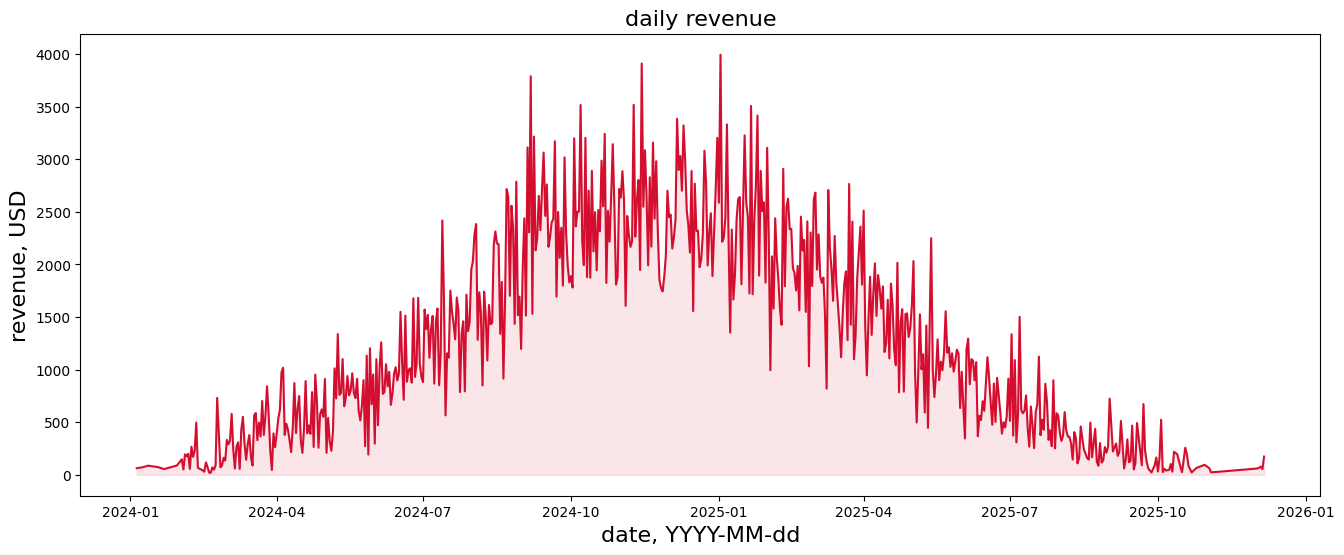

In [21]:
plt.figure(figsize=(16, 6))
plt.plot(daily_rev['date_extracted'], daily_rev['paid_price'], color="#D40E2F")

plt.title('daily revenue', fontsize=16)
plt.xlabel('date, YYYY-MM-dd', fontsize=16)
plt.ylabel('revenue, USD', fontsize=16)
plt.fill_between(daily_rev['date_extracted'], daily_rev['paid_price'], 
                 color="#D40E2F", 
                 alpha=0.1)

plt.show()

#### author metrics

In [22]:
num_unique_author_strings = df_books['author'].nunique()

print(f"Number of unique author entries: {num_unique_author_strings}")

Number of unique author entries: 374


In [23]:
def author_setting(author_str):
    if pd.isna(author_str):
        return ""
    authors = sorted([a.strip().lower() for a in str(author_str).split(',')])
    return ", ".join(authors)

In [24]:
df_books['author_set'] = df_books['author'].apply(author_setting)

In [25]:
print(f"Number of unique sets of authors: {df_books['author_set'].nunique()}")

Number of unique sets of authors: 325


#### unique users

In [26]:
fields = ['name', 'address', 'phone', 'email']

G = nx.Graph()
G.add_nodes_from(df_users['id'])

for combo in combinations(fields, 3):
    groups = df_users.groupby(list(combo))
    for _, group in groups:
        if len(group) > 1:
            uids = group['id'].tolist()
            for i in range(len(uids)):
                for j in range(i + 1, len(uids)):
                    G.add_edge(uids[i], uids[j])

unique_user_clusters = list(nx.connected_components(G))
print(f"Number of real unique users: {len(unique_user_clusters)}")

Number of real unique users: 3115


#### most popular author/set

In [27]:
df_sales_authors = df_orders.merge(df_books[['id', 'author_set']], left_on='book_id', right_on='id')

popularity = df_sales_authors.groupby('author_set')['quantity'].sum().sort_values(ascending=False)

most_popular = popularity.idxmax()
sales_count = popularity.max()

In [28]:
print(f"Most popular author(s): {most_popular}")
print(f"Total books sold: {sales_count}")

Most popular author(s): arlinda huel
Total books sold: 201


#### top spending customers

In [29]:
user_to_cluster = {}
for idx, cluster in enumerate(unique_user_clusters):
    for uid in cluster:
        user_to_cluster[uid] = idx

df_orders['cluster_id'] = df_orders['user_id'].map(user_to_cluster)

spending_per_user = df_orders.groupby('cluster_id')['paid_price'].sum()
top_cluster_idx = spending_per_user.idxmax()
total_spent = spending_per_user.max()

top_customer_ids = list(unique_user_clusters[top_cluster_idx])

top_customer_names = df_users[df_users['id'].isin(top_customer_ids)]['name'].unique().tolist()

In [30]:
print(f"Top customer names: {top_customer_names}")
print(f"Top customer total spending: ${total_spent:.2f}")
print(f"Original user_id values for this customer: {top_customer_ids}")

Top customer names: ['Rev. Johnson Olson', 'Yukiko Becker']
Top customer total spending: $1386.16
Original user_id values for this customer: [44850, 46955, 45062]


In [31]:
top_customer_rows = df_users[df_users['id'].isin(top_customer_ids)]
top_customer_rows.head()

,id,name,address,phone,email
373,45062,Rev. Johnson Olson,"Apt. 245 5042 Annette Islands, South Andrevill...",149.407.0465,jorge@hartmann-medhurst.example
1327,46955,Yukiko Becker,"Apt. 245 5042 Annette Islands, South Andrevill...",443 893 1024,jorge@hartmann-medhurst.example
2228,44850,Yukiko Becker,"Apt. 245 5042 Annette Islands, South Andrevill...",149.407.0465,jorge@hartmann-medhurst.example


### saving dfs for streamlit app

In [43]:
DATA_ID = 'DATA1'
FOLDER_PATH = f'dashboard_data/{DATA_ID}'

In [46]:
top_customer_rows.to_csv(f'{FOLDER_PATH}/top_customer_details.csv', index=False)

In [47]:
total_spent

np.savetxt(f'{FOLDER_PATH}/top_customer_total_spent.txt', [total_spent], fmt='%.2f')

In [48]:
top_5_days.to_csv(f'{FOLDER_PATH}/top_5_days.csv', index=False)

In [52]:
unique_author_set_num = df_books['author_set'].nunique()

with open(f"{FOLDER_PATH}/unique_authors.txt", "w") as f:
    f.write(str(unique_author_set_num))

In [53]:
unique_users_num = len(unique_user_clusters)

with open(f"{FOLDER_PATH}/unique_users.txt", "w") as f:
    f.write(str(unique_users_num))

In [57]:
popularity.to_csv(f'{FOLDER_PATH}/author_popularity.csv')

In [59]:
top_customer_rows.to_csv('top_customer_details.csv', index=False)

In [63]:
daily_rev.to_csv(f'{FOLDER_PATH}/daily_revenue.csv', index=False)